# Linear Regression — Theory and Practice
### Block 1 of Phase 1 · ML-Notes-and-Projects

This notebook is my study log for linear regression, combining the theoretical foundations from *An Introduction to Statistical Learning* (ISLP, Chapters 2-3) with the hands-on implementation approach from *Hands-On Machine Learning* (HOML, Chapter 4).

Instead of using ISLP's synthetic example ($Y=2+3X+\varepsilon$), here I work with a real, public dataset: the **Ames Housing dataset** (De Cock, 2011), which contains 2930 residential property sales in Ames, Iowa, described by 82 features (numerical + categorical) plus the target variable SalePrice.

### Goals of this notebook
1. Understand and implement **Simple Linear Regression** from scratch (Normal Equation + Gradient Descent), then validate against **scikit-learn** and **statsmodels**.
2. Extend to **Multiple Linear Regression**, including categorical predictors.
3. Understand and interpret **interferential statistics**: standar errors, the t-test for individual coefficients, the F-test for overall model significance, $R^2$/ adjusted $R^2$, and confidence intervals.
4. Check the **assumptions** behind the linear model (linearity, homoscedasticity, normality of residuals, multicollinearity).

### Dataset source
Ames Housing dataset, originally compiled by Dean De Cock as a modern, ethically-sourced alternative to the Boston Housing dataset. Source CSV: https://github.com/wblakecannon/ams (mirrors the original data relased for the Kaggle House Prices competition, unsplit).

# 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

np.random.seed(42)

# 1. First Look at the Data

In [3]:
df = pd.read_csv("housing.csv")
print(df.shape)
df.head()

(2930, 83)


,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2930 non-null   int64  
 1   Order            2930 non-null   int64  
 2   PID              2930 non-null   int64  
 3   MS SubClass      2930 non-null   int64  
 4   MS Zoning        2930 non-null   object 
 5   Lot Frontage     2440 non-null   float64
 6   Lot Area         2930 non-null   int64  
 7   Street           2930 non-null   object 
 8   Alley            198 non-null    object 
 9   Lot Shape        2930 non-null   object 
 10  Land Contour     2930 non-null   object 
 11  Utilities        2930 non-null   object 
 12  Lot Config       2930 non-null   object 
 13  Land Slope       2930 non-null   object 
 14  Neighborhood     2930 non-null   object 
 15  Condition 1      2930 non-null   object 
 16  Condition 2      2930 non-null   object 
 17  Bldg Type     

We have 2930 observations and 82 columns (81 predictors + SalePrice). A quick check on the target variable and on missing values:

In [5]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

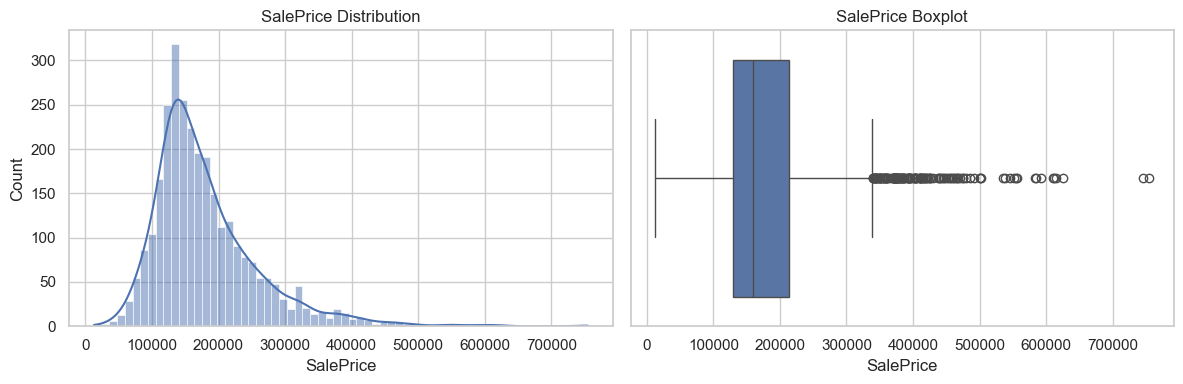

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice Distribution")
sns.boxplot(x=df["SalePrice"], ax=axes[1])
axes[1].set_title("SalePrice Boxplot")
plt.tight_layout()
plt.show()

SalePrice is right-skewed, as is typical for price data (a handful of expensive houses pull the mean above the median). We'll keep this in mind: it can affect the normality of residuals later on, and is a common reason practitioners model $\log{(\text{SalePrice})}$ instead. For now we work with the raw scale to keep the coefficient interpretation intuitive, and revisit this in the residual diagnostics section.

### 2. Choosing a Predictor for Simple Linear Regression

Before jumping into modeling, we need to pick *one numerical predictor* for the simple linear regression case. A natural approach is to rank all numerical features by their (Pearson) correlation with SalePrice.

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
correlations.head(11) #top 10 + SalePrice itself

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64

In [8]:
top_corr = correlations.drop("SalePrice").head(10)

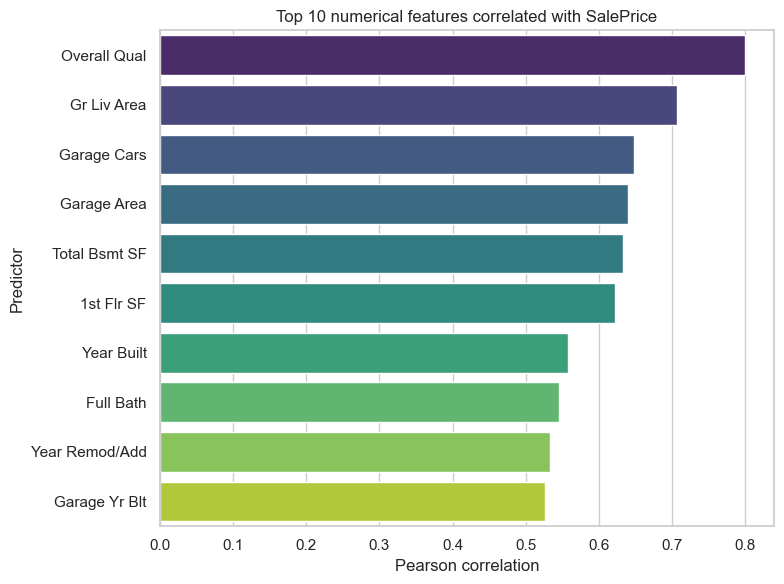

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette="viridis", legend=False)
plt.title("Top 10 numerical features correlated with SalePrice")
plt.xlabel("Pearson correlation")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

Overall Qual (overall material and finish quality, rated 1-10) actually shows the strongest linear correlation with SalePrice. However, it is worth pausing on what kind of variable this really is:
* Overall Qual is encoded as an integer (int64), but it is fundamentally an **ordinary categorical variable** (a rating scale), not a continuous measurement. Treating it as continuous in a regression is common practice and often reasonable, but it means the coefficient interpretation ("one more quality point $\to$ $X$ more") assumes equally spaced effects across the 1-10 scale, which is a stronger assumption than for a variable like square footage.
* Gr Liv Area (above-ground living area, in square feet) is a genuinely **continuous** variable, has the second-highest correlation, and has a very natural real-world interpretation: *bigger house* $\to$ *higher price*.

This is why we choose **Gr Liv Area** as our predictor for simple linear regression. This keeps the first pass conceptually clean (a true continuous $X\to Y$ relationship) before we deal with the added complexity of ordinal and categorical predictors in the multiple regression section.

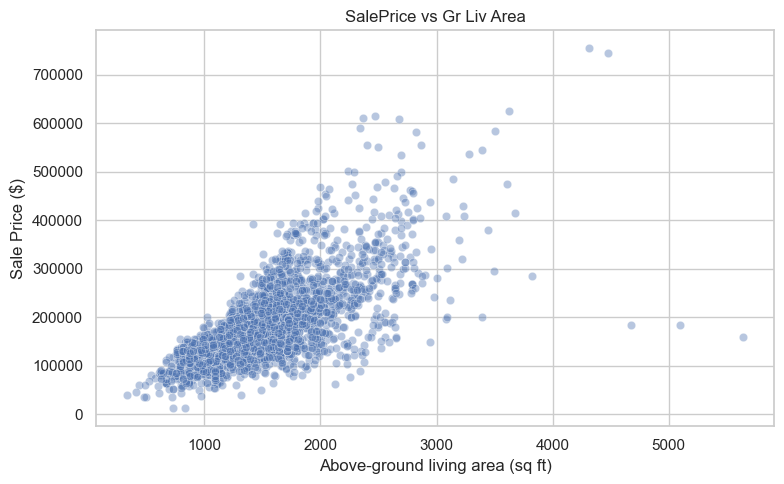

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Gr Liv Area", y="SalePrice", alpha=0.4)
plt.title("SalePrice vs Gr Liv Area")
plt.xlabel("Above-ground living area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.show()

This relationship looks reasonably linear, with variance that appears to increase somewhat for larget houses (a first, informal hint of possible **heteroscedasticity**, which we will check formaly later with residual plots). There's also a couple of visible outliers — very large houses sold at a comparatively low price — which we'll keep in mind but not remove, to stay close to how a real dataset behaves.

Let's isolate our working variables and drop any rows with missing values in either column (there shouldn't be any here, but it's good practice to check explicitly).

In [13]:
print("Missing in Gr Liv Area:", df["Gr Liv Area"].isna().sum())
print("Missing in SalePrice:", df["SalePrice"].isna().sum())

simple_df = df[["Gr Liv Area", "SalePrice"]].dropna().reset_index(drop=True)
simple_df.describe()

Missing in Gr Liv Area: 0
Missing in SalePrice: 0


,Gr Liv Area,SalePrice
count,2930.000000,2930.000000
mean,1499.690444,180796.060068
std,505.508887,79886.692357
min,334.000000,12789.000000
25%,1126.000000,129500.000000
50%,1442.000000,160000.000000
75%,1742.750000,213500.000000
max,5642.000000,755000.000000


### Train / test split

Even though our goal here is mostly *inferential* (understanding the relationship and its statistical significance) rather than purely *predictive*, we still split into train and test sets. This lets us later evaluate how well the fitted line generalizes to unseen data — a habit worth building from the very first model onward, since in later blocks this split is not optional.

In [14]:
X = simple_df[["Gr Liv Area"]].values # keeps as 2D array: shape (n_samples, 1)
y = simple_df["SalePrice"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 2344 | Test size: 586
